# ALBEF Model Test Results — BNS/NSBH Classification

Results from: `Model/eval_results/bns_nsbh_test_v8/eval_results.json`

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

In [13]:
import os
_BASE = os.environ.get('BASE_DIR', '/fred/oz016/bgao_kn')

EVAL_DIR = Path('../Model/eval_results/cls_test/bns_nsbh_test_full')
OUT_DIR = Path(f"{_BASE}/gw-kn-multimodal/figures")
SAVE_DIR = OUT_DIR / "test_results"  # save plots alongside results


with open(EVAL_DIR / 'eval_results.json') as f:
    results = json.load(f)

print(json.dumps(results['classification_by_source'], indent=2))

{
  "bns": {
    "metrics": {
      "n_dropped_nonfinite": 0,
      "auroc": 0.9817728400230408,
      "auprc": 0.9629614949226379,
      "f1_optimal": 0.9152411222457886,
      "f1_threshold": 0.44999998807907104,
      "ece": 0.014313798323188005,
      "tp": 4668,
      "fp": 424,
      "tn": 10102,
      "fn": 463,
      "accuracy": 0.9433480232483873,
      "precision": 0.9167321288295365,
      "recall": 0.9097641785227051,
      "f1": 0.9132348625648048,
      "precision_confusion": 0.9167321288295365,
      "recall_confusion": 0.9097641785227051,
      "f1_confusion": 0.9132348625648048
    },
    "pair_type_counts": {
      "n_total": 15657,
      "n_positive": 5131,
      "n_optical_neg": 5131,
      "n_gw_neg": 333,
      "n_hard_neg": 5062
    }
  },
  "nsbh": {
    "metrics": {
      "n_dropped_nonfinite": 0,
      "auroc": 0.9793033599853516,
      "auprc": 0.9195215702056885,
      "f1_optimal": 0.868283212184906,
      "f1_threshold": 0.5099999904632568,
      "ece": 0.

## Confusion Matrices — BNS and NSBH

In [14]:
def plot_confusion_matrix(
    ax, tp, fp, tn, fn,
    title, metrics=None,
    cmap='Blues', normalize=True
):
    """
    Plot a 2x2 confusion matrix on ax.

    Layout (scikit-learn convention):
        rows = actual label, cols = predicted label
        [[TN, FP],
         [FN, TP]]
    """
    cm_raw = np.array([[tn, fp],
                        [fn, tp]], dtype=float)

    if normalize:
        row_sums = cm_raw.sum(axis=1, keepdims=True)
        cm_plot = cm_raw / row_sums
    else:
        cm_plot = cm_raw

    im = ax.imshow(cm_plot, interpolation='nearest', cmap=cmap,
                   vmin=0, vmax=1 if normalize else None)
    
    # 获取 colorbar 对象并设置刻度数字大小
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=12)

    labels = ['Negative', 'Positive']
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_yticklabels(labels, fontsize=12)
    ax.set_xlabel('Predicted label', fontsize=14)
    ax.set_ylabel('True label', fontsize=14)

    thresh = cm_plot.max() / 2.0
    cell_labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            val = cm_plot[i, j]
            raw = int(cm_raw[i, j])
            pct_str = f'{val:.1%}' if normalize else ''
            txt = f'{cell_labels[i][j]}\n{raw:,}'
            if normalize:
                txt += f'\n({pct_str})'
            color = 'white' if val > thresh else 'black'
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=12, color=color, fontweight='bold')

    subtitle = ''
    if metrics is not None:
        prec = metrics.get('precision_confusion', metrics['tp'] / (metrics['tp'] + metrics['fp']))
        rec  = metrics.get('recall_confusion',    metrics['tp'] / (metrics['tp'] + metrics['fn']))
        f1   = metrics.get('f1_confusion',        2 * prec * rec / (prec + rec))
        auroc = metrics['auroc']
        # subtitle = (f'AUROC={auroc:.3f}  |  '
        #             f'Precision={prec:.3f}  |  '
        #             f'Recall={rec:.3f}  |  '
        #             f'F1={f1:.3f}')

    full_title = title
    if subtitle:
        full_title += f'\n{subtitle}'
    ax.set_title(full_title, fontsize=14, pad=10)

Saved → /fred/oz016/bgao_kn/gw-kn-multimodal/figures/test_results/confusion_matrix_bns_nsbh.pdf


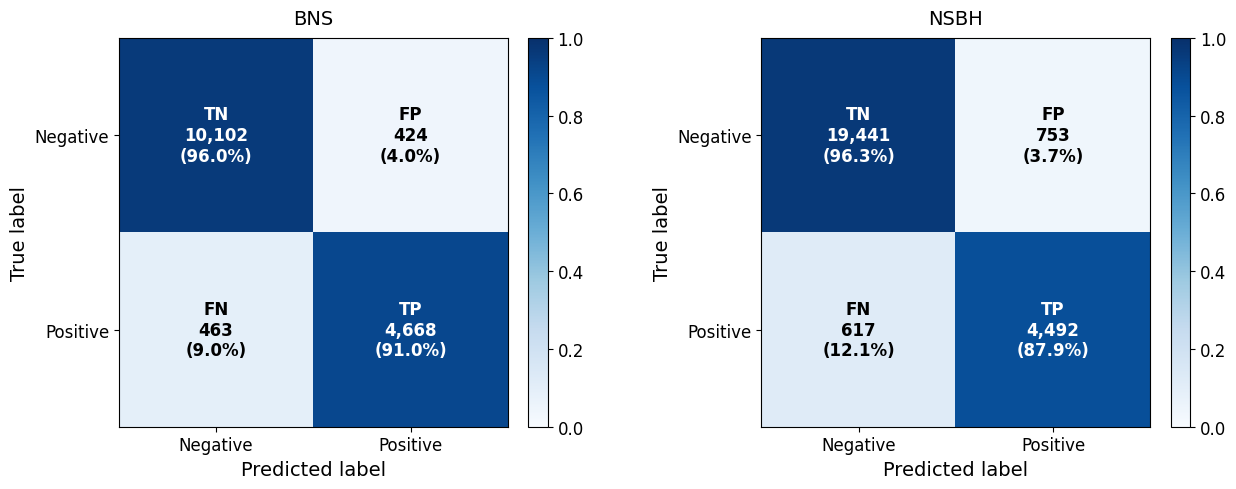

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# fig.suptitle('BNS / NSBH Binary Classification',
#              fontsize=14, y=1.02)

for ax, source in zip(axes, ['bns', 'nsbh']):
    m = results['classification_by_source'][source]['metrics']
    plot_confusion_matrix(
        ax,
        tp=m['tp'], fp=m['fp'], tn=m['tn'], fn=m['fn'],
        title=source.upper(),
        metrics=m,
        normalize=True,
    )

plt.tight_layout()
save_path = SAVE_DIR / 'confusion_matrix_bns_nsbh.pdf'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

## Combined overview — all pairs

Saved → /fred/oz016/bgao_kn/gw-kn-multimodal/figures/test_results/confusion_matrix_all.png


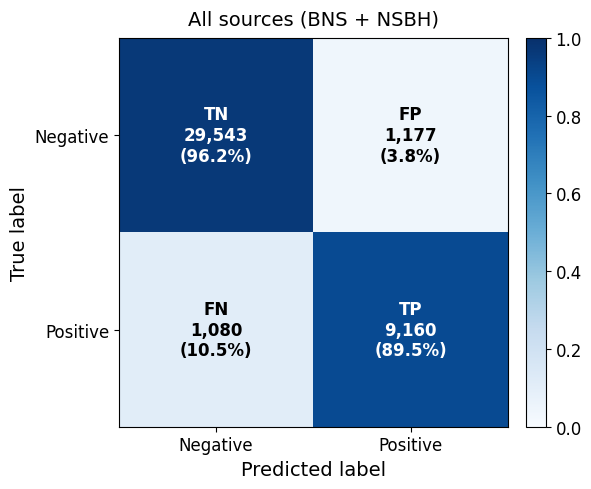

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))

m = results['classification']
plot_confusion_matrix(
    ax,
    tp=m['tp'], fp=m['fp'], tn=m['tn'], fn=m['fn'],
    title='All sources (BNS + NSBH)',
    metrics=m,
    normalize=True,
)

plt.tight_layout()
save_path = SAVE_DIR / 'confusion_matrix_all.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()